# Laplace Problem 6: Rectangular Region, Solved Numerically with and without Numba

This notebook is based on **Problem 6** from `problems/laplace_equation_test.tex` and the corresponding `problems/Laplace_equation.pdf` problem set:

$$
\nabla^2\Phi=0
\qquad
\text{in } 0<x<a,\;0<y<b,
$$

with boundary conditions

$$
\Phi(0,y)=0,
\qquad
\Phi(a,y)=0,
\qquad
\Phi(x,0)=0,
\qquad
\Phi(x,b)=V_0\sin\left(\frac{\pi x}{a}\right).
$$

The notebook does three things:

1. writes down the exact separation-of-variables solution,
2. solves the same boundary-value problem numerically with finite-difference SOR,
3. benchmarks the same solver written in pure Python loops and with `numba.njit`.


## Exact Solution and Discrete Update Rule

For this boundary data the exact solution is

$$
\Phi(x,y)=V_0\,\frac{\sinh\left(\frac{\pi y}{a}\right)}{\sinh\left(\frac{\pi b}{a}\right)}\sin\left(\frac{\pi x}{a}\right).
$$

To solve the same problem numerically, place a grid on the rectangle and approximate Laplace's equation by the five-point stencil

$$
\frac{\Phi_{i+1,j}-2\Phi_{i,j}+\Phi_{i-1,j}}{h_x^2}
+
\frac{\Phi_{i,j+1}-2\Phi_{i,j}+\Phi_{i,j-1}}{h_y^2}=0.
$$

Solving for the updated interior value gives

$$
\Phi_{i,j}^{\rm new}=
\frac{h_y^2\left(\Phi_{i+1,j}+\Phi_{i-1,j}\right)+h_x^2\left(\Phi_{i,j+1}+\Phi_{i,j-1}\right)}{2(h_x^2+h_y^2)}.
$$

We then use **successive over-relaxation** (SOR):

$$
\Phi_{i,j}\leftarrow (1-\omega)\Phi_{i,j}+\omega\Phi_{i,j}^{\rm new}.
$$

The numerical comparison below uses the same SOR algorithm in both cases. The only difference is that one version is interpreted Python and the other is JIT-compiled by Numba.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from time import perf_counter

try:
    from numba import njit
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook needs a Python environment with `numba` installed. "
    ) from exc

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
def top_boundary(x, a=1.0, V0=1.0):
    return V0 * np.sin(np.pi * x / a)


def exact_solution(x, y, a=1.0, b=1.0, V0=1.0):
    X, Y = np.meshgrid(x, y, indexing="ij")
    return V0 * np.sin(np.pi * X / a) * np.sinh(np.pi * Y / a) / np.sinh(np.pi * b / a)


def make_boundary_array(x, y, a=1.0, V0=1.0):
    phi = np.zeros((x.size, y.size), dtype=np.float64)
    phi[:, -1] = top_boundary(x, a=a, V0=V0)
    return phi


def laplace_residual_numpy(phi, hx, hy):
    lap = (
        (phi[2:, 1:-1] - 2.0 * phi[1:-1, 1:-1] + phi[:-2, 1:-1]) / hx**2
        + (phi[1:-1, 2:] - 2.0 * phi[1:-1, 1:-1] + phi[1:-1, :-2]) / hy**2
    )
    return np.max(np.abs(lap))


def solve_laplace_sor_python(
    phi_boundary,
    hx,
    hy,
    omega=1.93,
    tol=1e-7,
    max_iter=10000,
    check_every=20,
):
    phi = np.array(phi_boundary, dtype=np.float64, copy=True)
    nx, ny = phi.shape
    denom = 2.0 * (hx**2 + hy**2)
    history = []

    for step in range(1, max_iter + 1):
        for j in range(1, ny - 1):
            for i in range(1, nx - 1):
                updated = (
                    hy**2 * (phi[i + 1, j] + phi[i - 1, j])
                    + hx**2 * (phi[i, j + 1] + phi[i, j - 1])
                ) / denom
                phi[i, j] = (1.0 - omega) * phi[i, j] + omega * updated

        if step == 1 or step % check_every == 0:
            residual = laplace_residual_numpy(phi, hx, hy)
            history.append(residual)
            if residual < tol:
                return phi, np.array(history), step

    return phi, np.array(history), max_iter


@njit
def laplace_residual_numba(phi, hx, hy):
    nx, ny = phi.shape
    max_abs = 0.0
    inv_hx2 = 1.0 / (hx * hx)
    inv_hy2 = 1.0 / (hy * hy)

    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            lap = (
                (phi[i + 1, j] - 2.0 * phi[i, j] + phi[i - 1, j]) * inv_hx2
                + (phi[i, j + 1] - 2.0 * phi[i, j] + phi[i, j - 1]) * inv_hy2
            )
            val = abs(lap)
            if val > max_abs:
                max_abs = val

    return max_abs


@njit
def solve_laplace_sor_numba(
    phi_boundary,
    hx,
    hy,
    omega=1.93,
    tol=1e-7,
    max_iter=10000,
    check_every=20,
):
    phi = phi_boundary.copy()
    nx, ny = phi.shape
    denom = 2.0 * (hx * hx + hy * hy)
    history = np.empty(max_iter // check_every + 2, dtype=np.float64)
    count = 0

    for step in range(1, max_iter + 1):
        for j in range(1, ny - 1):
            for i in range(1, nx - 1):
                updated = (
                    hy * hy * (phi[i + 1, j] + phi[i - 1, j])
                    + hx * hx * (phi[i, j + 1] + phi[i, j - 1])
                ) / denom
                phi[i, j] = (1.0 - omega) * phi[i, j] + omega * updated

        if step == 1 or step % check_every == 0:
            residual = laplace_residual_numba(phi, hx, hy)
            history[count] = residual
            count += 1
            if residual < tol:
                return phi, history[:count], step

    return phi, history[:count], max_iter


def relative_l2_error(numerical, exact):
    diff = numerical[1:-1, 1:-1] - exact[1:-1, 1:-1]
    ref = exact[1:-1, 1:-1]
    return np.sqrt(np.mean(diff**2)) / np.sqrt(np.mean(ref**2))


In [3]:
a = 1.0
b = 1.0
V0 = 1.0
Nx = 101
Ny = 101

x = np.linspace(0.0, a, Nx)
y = np.linspace(0.0, b, Ny)
hx = x[1] - x[0]
hy = y[1] - y[0]

omega = 1.93
tol = 1e-7
max_iter = 10000
check_every = 20

phi_boundary = make_boundary_array(x, y, a=a, V0=V0)
phi_exact = exact_solution(x, y, a=a, b=b, V0=V0)

print(f"Grid: {Nx} x {Ny}")
print(f"Spacing: hx = {hx:.4f}, hy = {hy:.4f}")
print(f"SOR parameter omega = {omega}")


Grid: 101 x 101
Spacing: hx = 0.0100, hy = 0.0100
SOR parameter omega = 1.93


## Benchmark Run

The first Numba call includes JIT compilation. The second Numba call is the fair steady-state timing.

In [4]:
start = perf_counter()
phi_python, history_python, iterations_python = solve_laplace_sor_python(
    phi_boundary,
    hx,
    hy,
    omega=omega,
    tol=tol,
    max_iter=max_iter,
    check_every=check_every,
)
time_python = perf_counter() - start

start = perf_counter()
phi_numba_first, history_numba_first, iterations_numba_first = solve_laplace_sor_numba(
    phi_boundary,
    hx,
    hy,
    omega=omega,
    tol=tol,
    max_iter=max_iter,
    check_every=check_every,
)
time_numba_first = perf_counter() - start

start = perf_counter()
phi_numba, history_numba, iterations_numba = solve_laplace_sor_numba(
    phi_boundary,
    hx,
    hy,
    omega=omega,
    tol=tol,
    max_iter=max_iter,
    check_every=check_every,
)
time_numba = perf_counter() - start


In [5]:
python_max_error = np.max(np.abs(phi_python[1:-1, 1:-1] - phi_exact[1:-1, 1:-1]))
python_rel_l2 = relative_l2_error(phi_python, phi_exact)

numba_max_error = np.max(np.abs(phi_numba[1:-1, 1:-1] - phi_exact[1:-1, 1:-1]))
numba_rel_l2 = relative_l2_error(phi_numba, phi_exact)

solution_difference = np.max(np.abs(phi_python - phi_numba))
history_steps = np.array([1] + list(range(check_every, check_every * len(history_python), check_every)))[: len(history_python)]

print(f"Python iterations: {iterations_python}")
print(f"Numba iterations:  {iterations_numba}")
print(f"Final residual:    {history_python[-1]:.3e}")
print()
print(f"Python max error:  {python_max_error:.3e}")
print(f"Numba max error:   {numba_max_error:.3e}")
print(f"Python rel L2:     {python_rel_l2:.3e}")
print(f"Numba rel L2:      {numba_rel_l2:.3e}")
print(f"Max |Python - Numba|: {solution_difference:.3e}")

assert np.allclose(phi_python, phi_numba)


Python iterations: 560
Numba iterations:  560
Final residual:    8.413e-08

Python max error:  2.852e-05
Numba max error:   2.852e-05
Python rel L2:     5.043e-05
Numba rel L2:      5.043e-05
Max |Python - Numba|: 0.000e+00


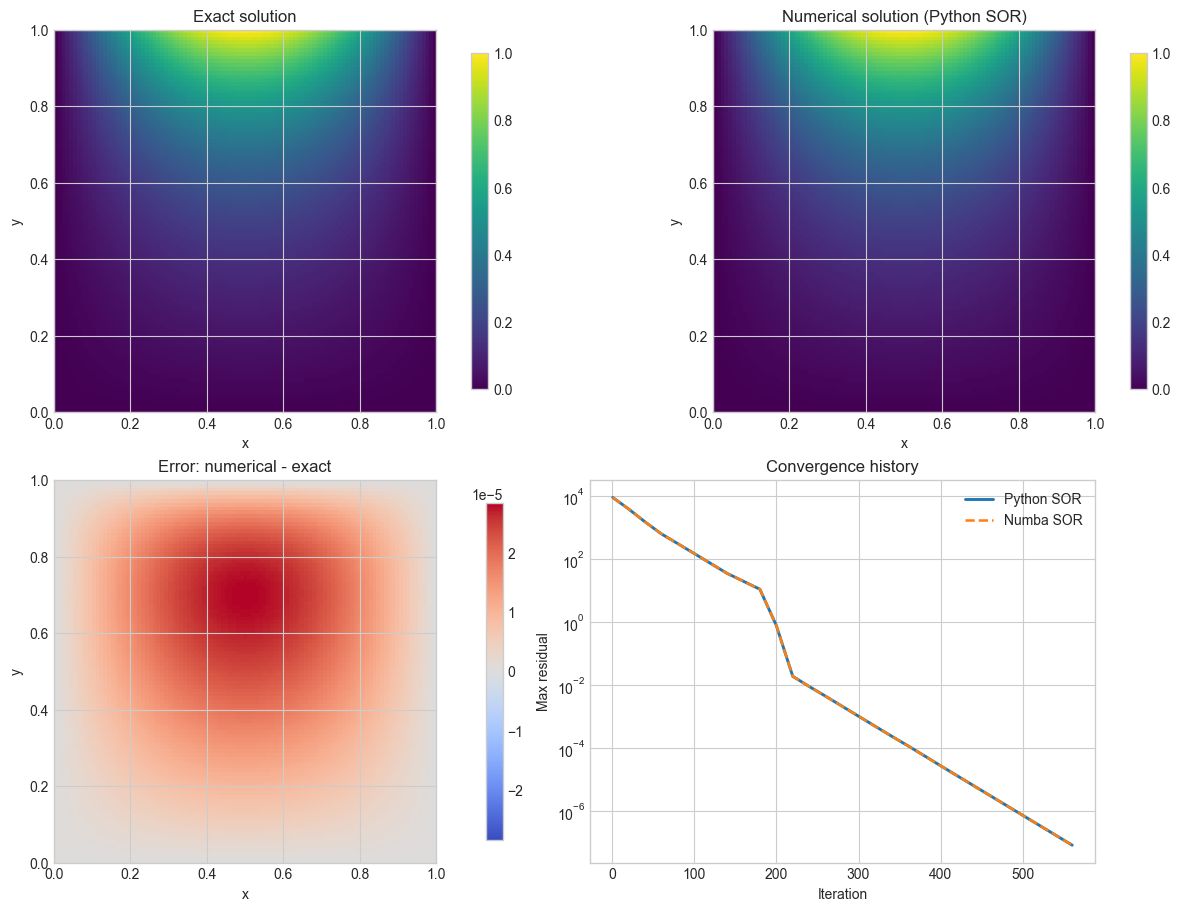

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0), constrained_layout=True)

im0 = axes[0, 0].imshow(phi_exact.T, origin="lower", extent=(0, a, 0, b), cmap="viridis")
axes[0, 0].set_title("Exact solution")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0, 0], shrink=0.88)

im1 = axes[0, 1].imshow(phi_python.T, origin="lower", extent=(0, a, 0, b), cmap="viridis")
axes[0, 1].set_title("Numerical solution (Python SOR)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
fig.colorbar(im1, ax=axes[0, 1], shrink=0.88)

error_field = phi_python - phi_exact
error_scale = np.max(np.abs(error_field[1:-1, 1:-1]))
im2 = axes[1, 0].imshow(
    error_field.T,
    origin="lower",
    extent=(0, a, 0, b),
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-error_scale, vcenter=0.0, vmax=error_scale),
)
axes[1, 0].set_title("Error: numerical - exact")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
fig.colorbar(im2, ax=axes[1, 0], shrink=0.88)

axes[1, 1].semilogy(history_steps, history_python, linewidth=2.1, label="Python SOR")
axes[1, 1].semilogy(history_steps, history_numba, "--", linewidth=1.8, label="Numba SOR")
axes[1, 1].set_title("Convergence history")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Max residual")
axes[1, 1].legend()

plt.show()


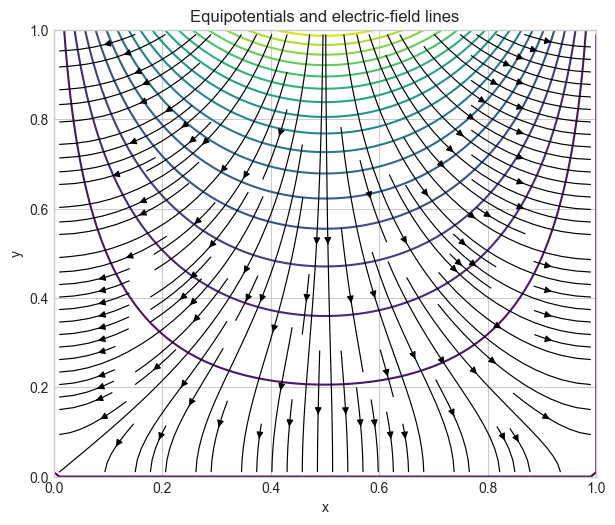

In [7]:
Ex = -(phi_numba[2:, 1:-1] - phi_numba[:-2, 1:-1]) / (2.0 * hx)
Ey = -(phi_numba[1:-1, 2:] - phi_numba[1:-1, :-2]) / (2.0 * hy)

fig, ax = plt.subplots(figsize=(7.0, 5.8))
ax.contour(x, y, phi_numba.T, levels=16, cmap="viridis")
ax.streamplot(x[1:-1], y[1:-1], Ex.T, Ey.T, color="black", density=1.2, linewidth=0.85, arrowsize=1.0)
ax.set_title("Equipotentials and electric-field lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


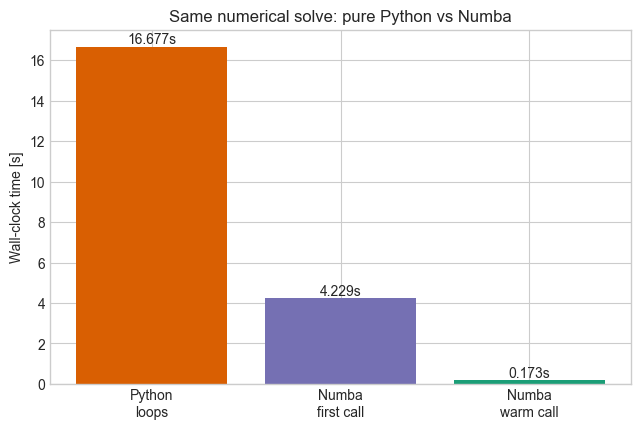

Pure Python time:         16.677 s
Numba first-call time:    4.229 s
Numba warm-call time:     0.173 s

Speedup including compile: 3.94x
Steady-state speedup:      96.31x


In [8]:
labels = ["Python\nloops", "Numba\nfirst call", "Numba\nwarm call"]
times = np.array([time_python, time_numba_first, time_numba])
colors = ["#d95f02", "#7570b3", "#1b9e77"]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.bar(labels, times, color=colors)
ax.set_ylabel("Wall-clock time [s]")
ax.set_title("Same numerical solve: pure Python vs Numba")

for bar, value in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2.0, value, f"{value:.3f}s", ha="center", va="bottom")

plt.show()

speedup_first = time_python / time_numba_first
speedup_warm = time_python / time_numba

print(f"Pure Python time:         {time_python:.3f} s")
print(f"Numba first-call time:    {time_numba_first:.3f} s")
print(f"Numba warm-call time:     {time_numba:.3f} s")
print()
print(f"Speedup including compile: {speedup_first:.2f}x")
print(f"Steady-state speedup:      {speedup_warm:.2f}x")


## What This Shows

- The numerical SOR solution matches the analytic separation-of-variables solution closely.
- The pure Python and Numba solvers converge in exactly the same number of iterations because they are the same algorithm.
- The first Numba call pays a compilation cost, so the warm-call timing is the right number for repeated solves or parameter sweeps.
- For loop-heavy finite-difference solvers like this one, `@njit` can reduce runtime by more than an order of magnitude without changing the numerical method itself.
